
# <span style="color:rgb(213,80,0)">Data loading</span>

In [1]:
load CRIM.mat
Y = CRIM; % Assuming CRIM is a table or matrix loaded from the .mat file

## Figure 3 left panel: Traditional non robust PCA

The first PC already explains more than 0.95^v variability
In what follows we still extract the first 2 PCs
Initial correlation matrix
              PERSON    THEFTS    ROBERY    ORGFNC    PUBSAF    OTHERS    SEIZED    SHADOW
              ______    ______    ______    ______    ______    ______    ______    ______
    PERSON     1.00      0.94      0.92      0.98      0.74      0.97      0.82      0.96 
    THEFTS     0.94      1.00      0.93      0.96      0.68      0.97      0.77      0.97 
    ROBERY     0.92      0.93      1.00      0.91      0.65      0.92      0.72      0.91 
    ORGFNC     0.98      0.96      0.91      1.00      0.73      0.98      0.81      0.97 
    PUBSAF     0.74      0.68      0.65      0.73      1.00      0.74      0.68      0.71 
    OTHERS     0.97      0.97      0.92      0.98      0.74      1.00      0.79      0.97 
    SEIZED     0.82      0.77      0.72      0.81      0.68      0.79      1.00      0.80 
    SHADOW     0.96      0.97      0.91      0


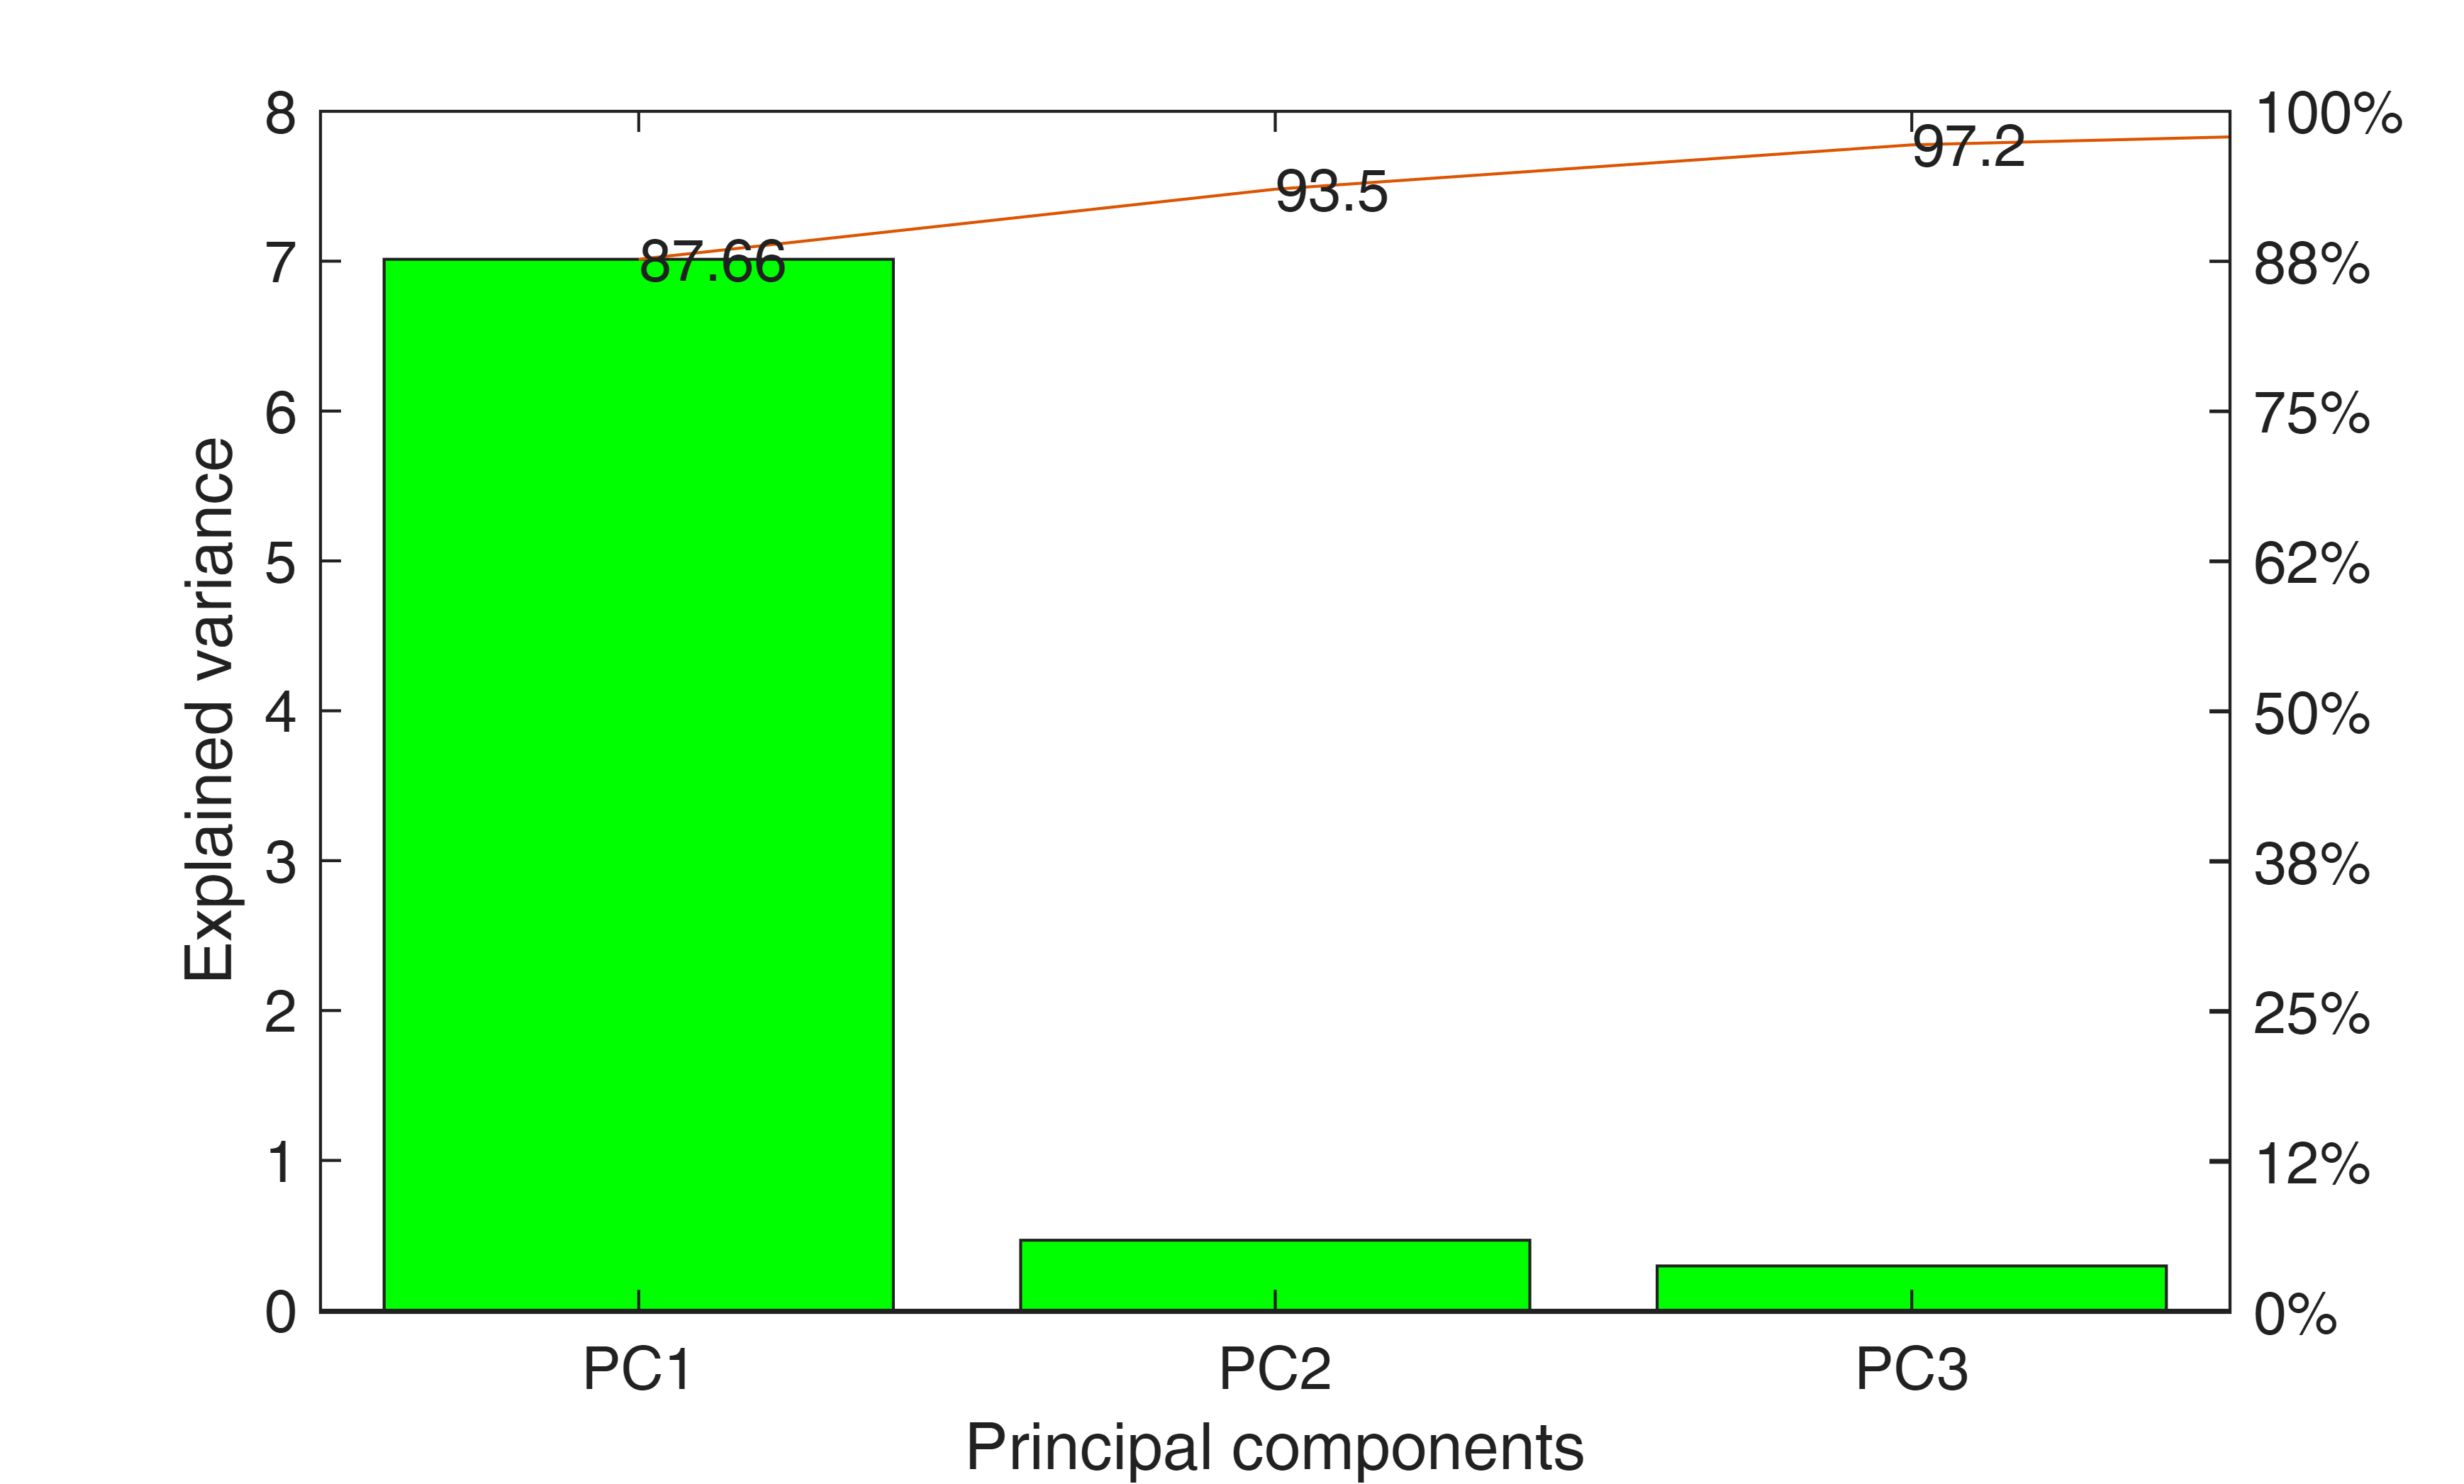


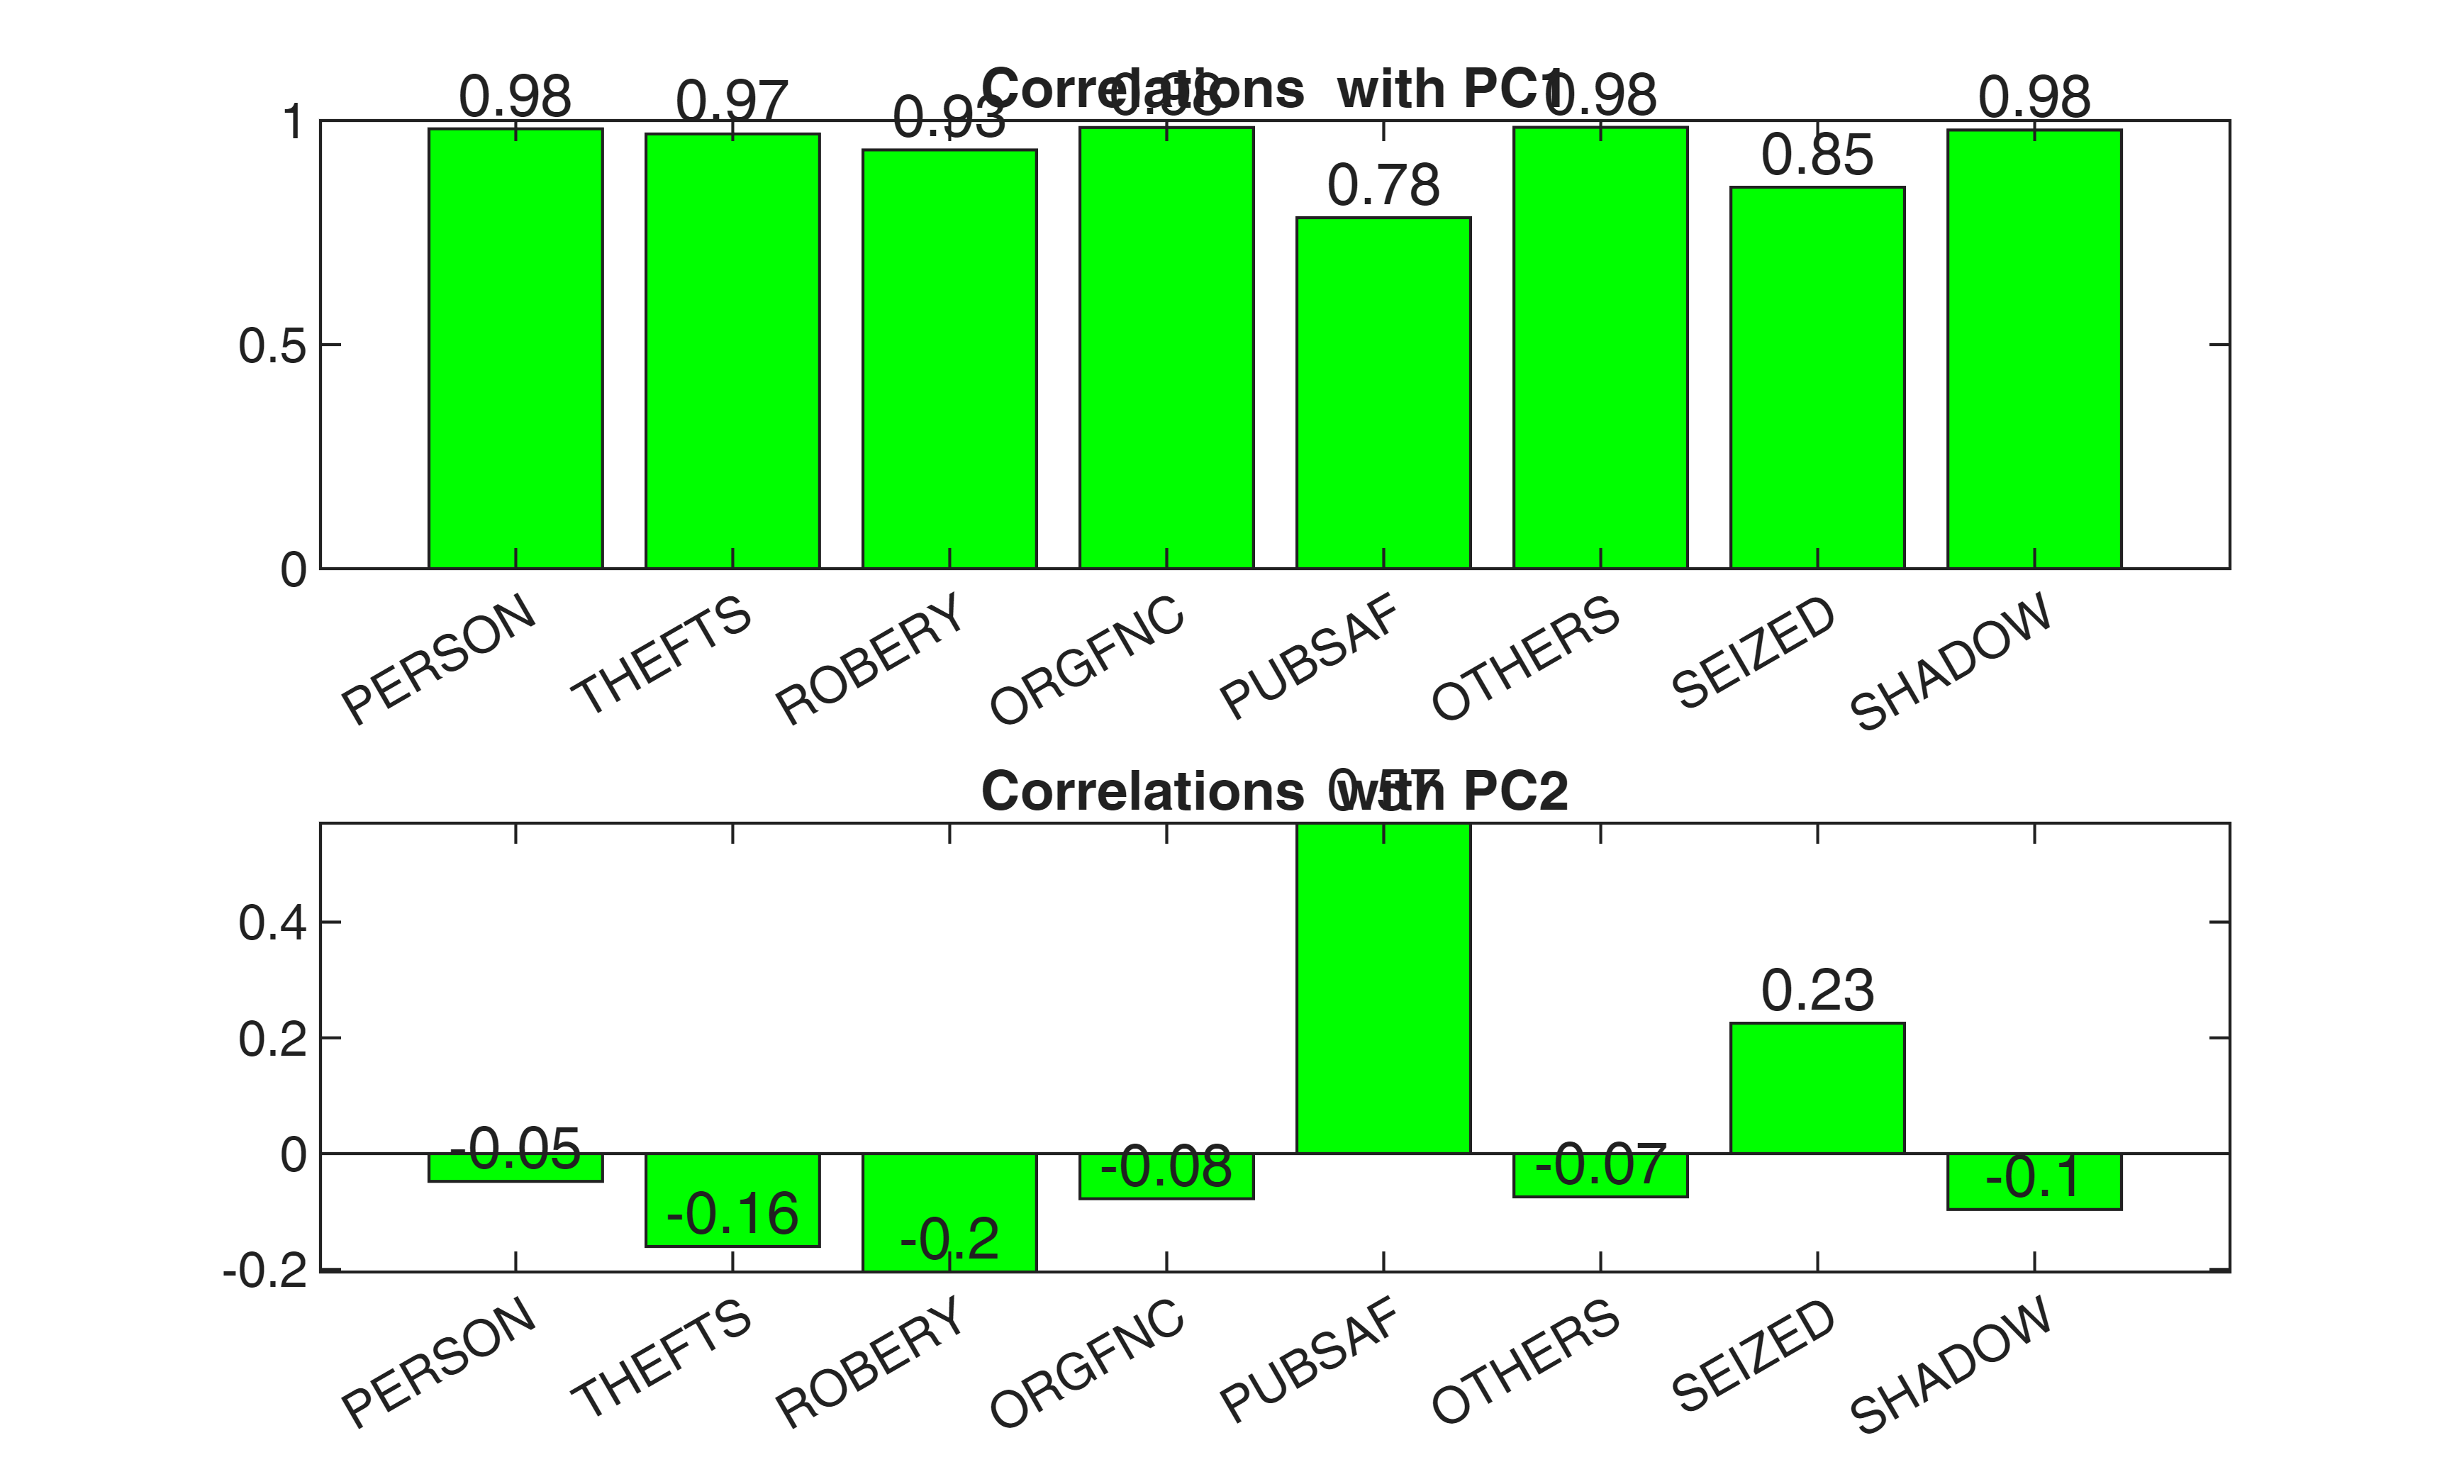

In [2]:
out=pcaFS(Y,"smartEVchart",true);

<center>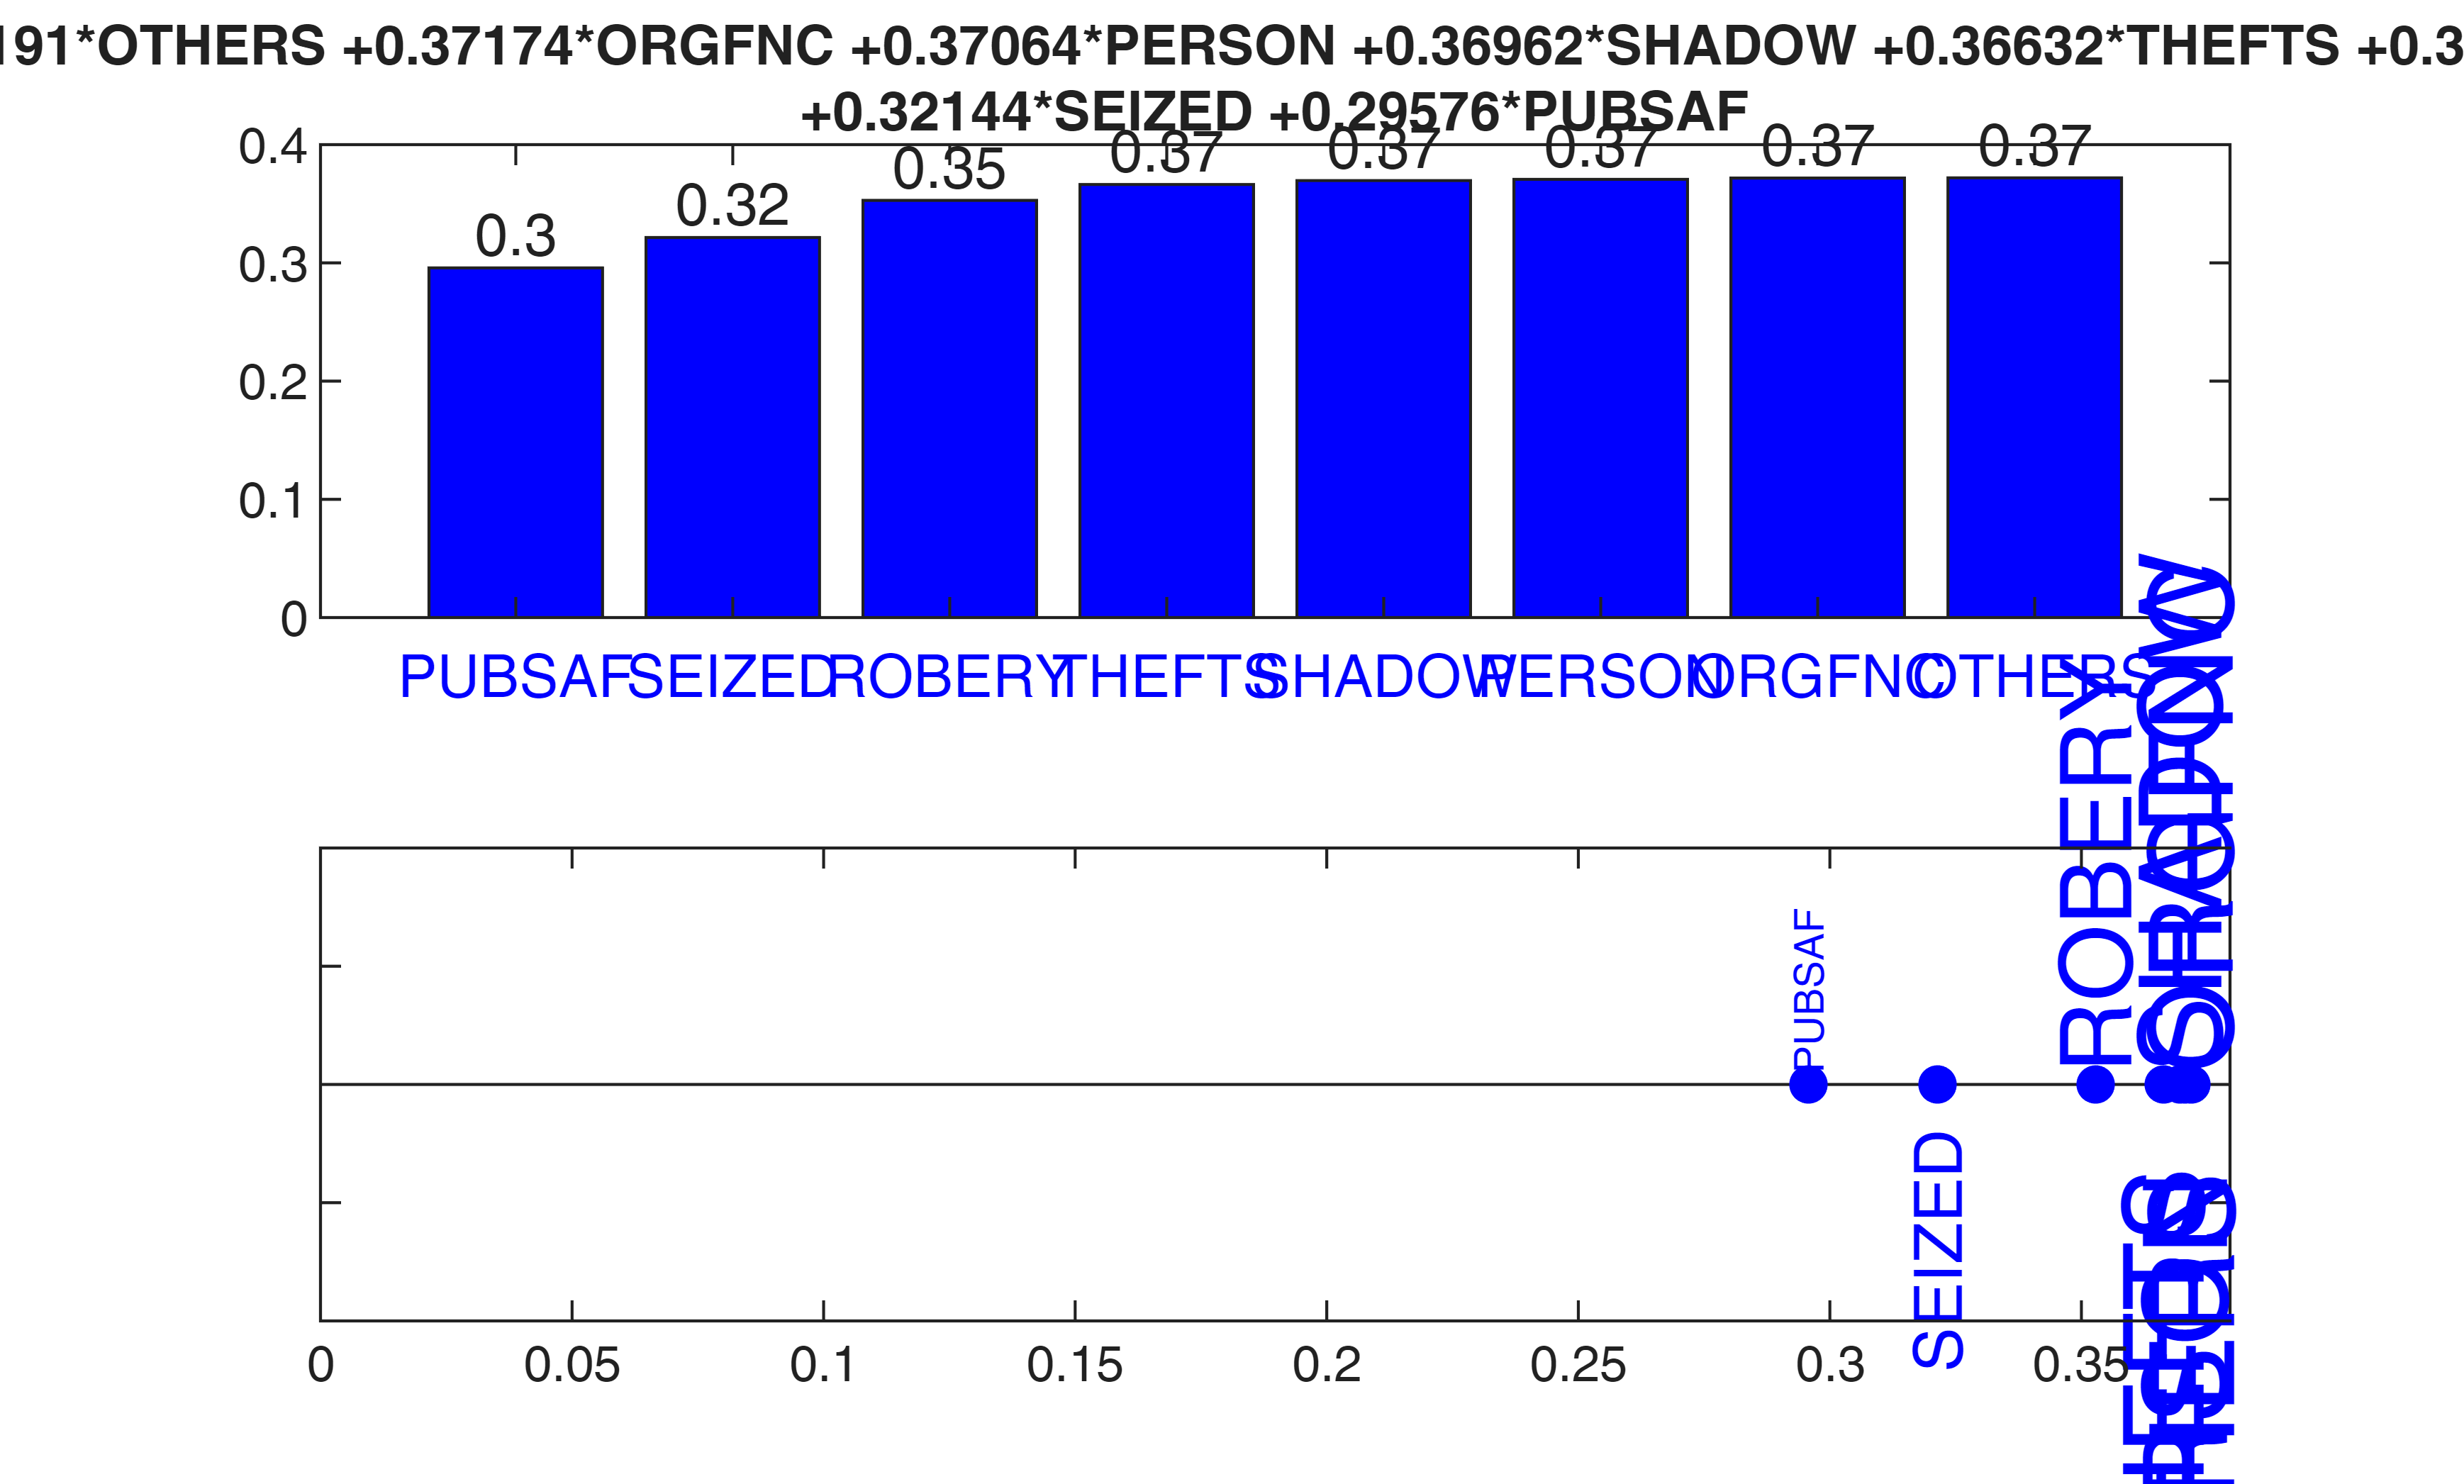</center>


<center>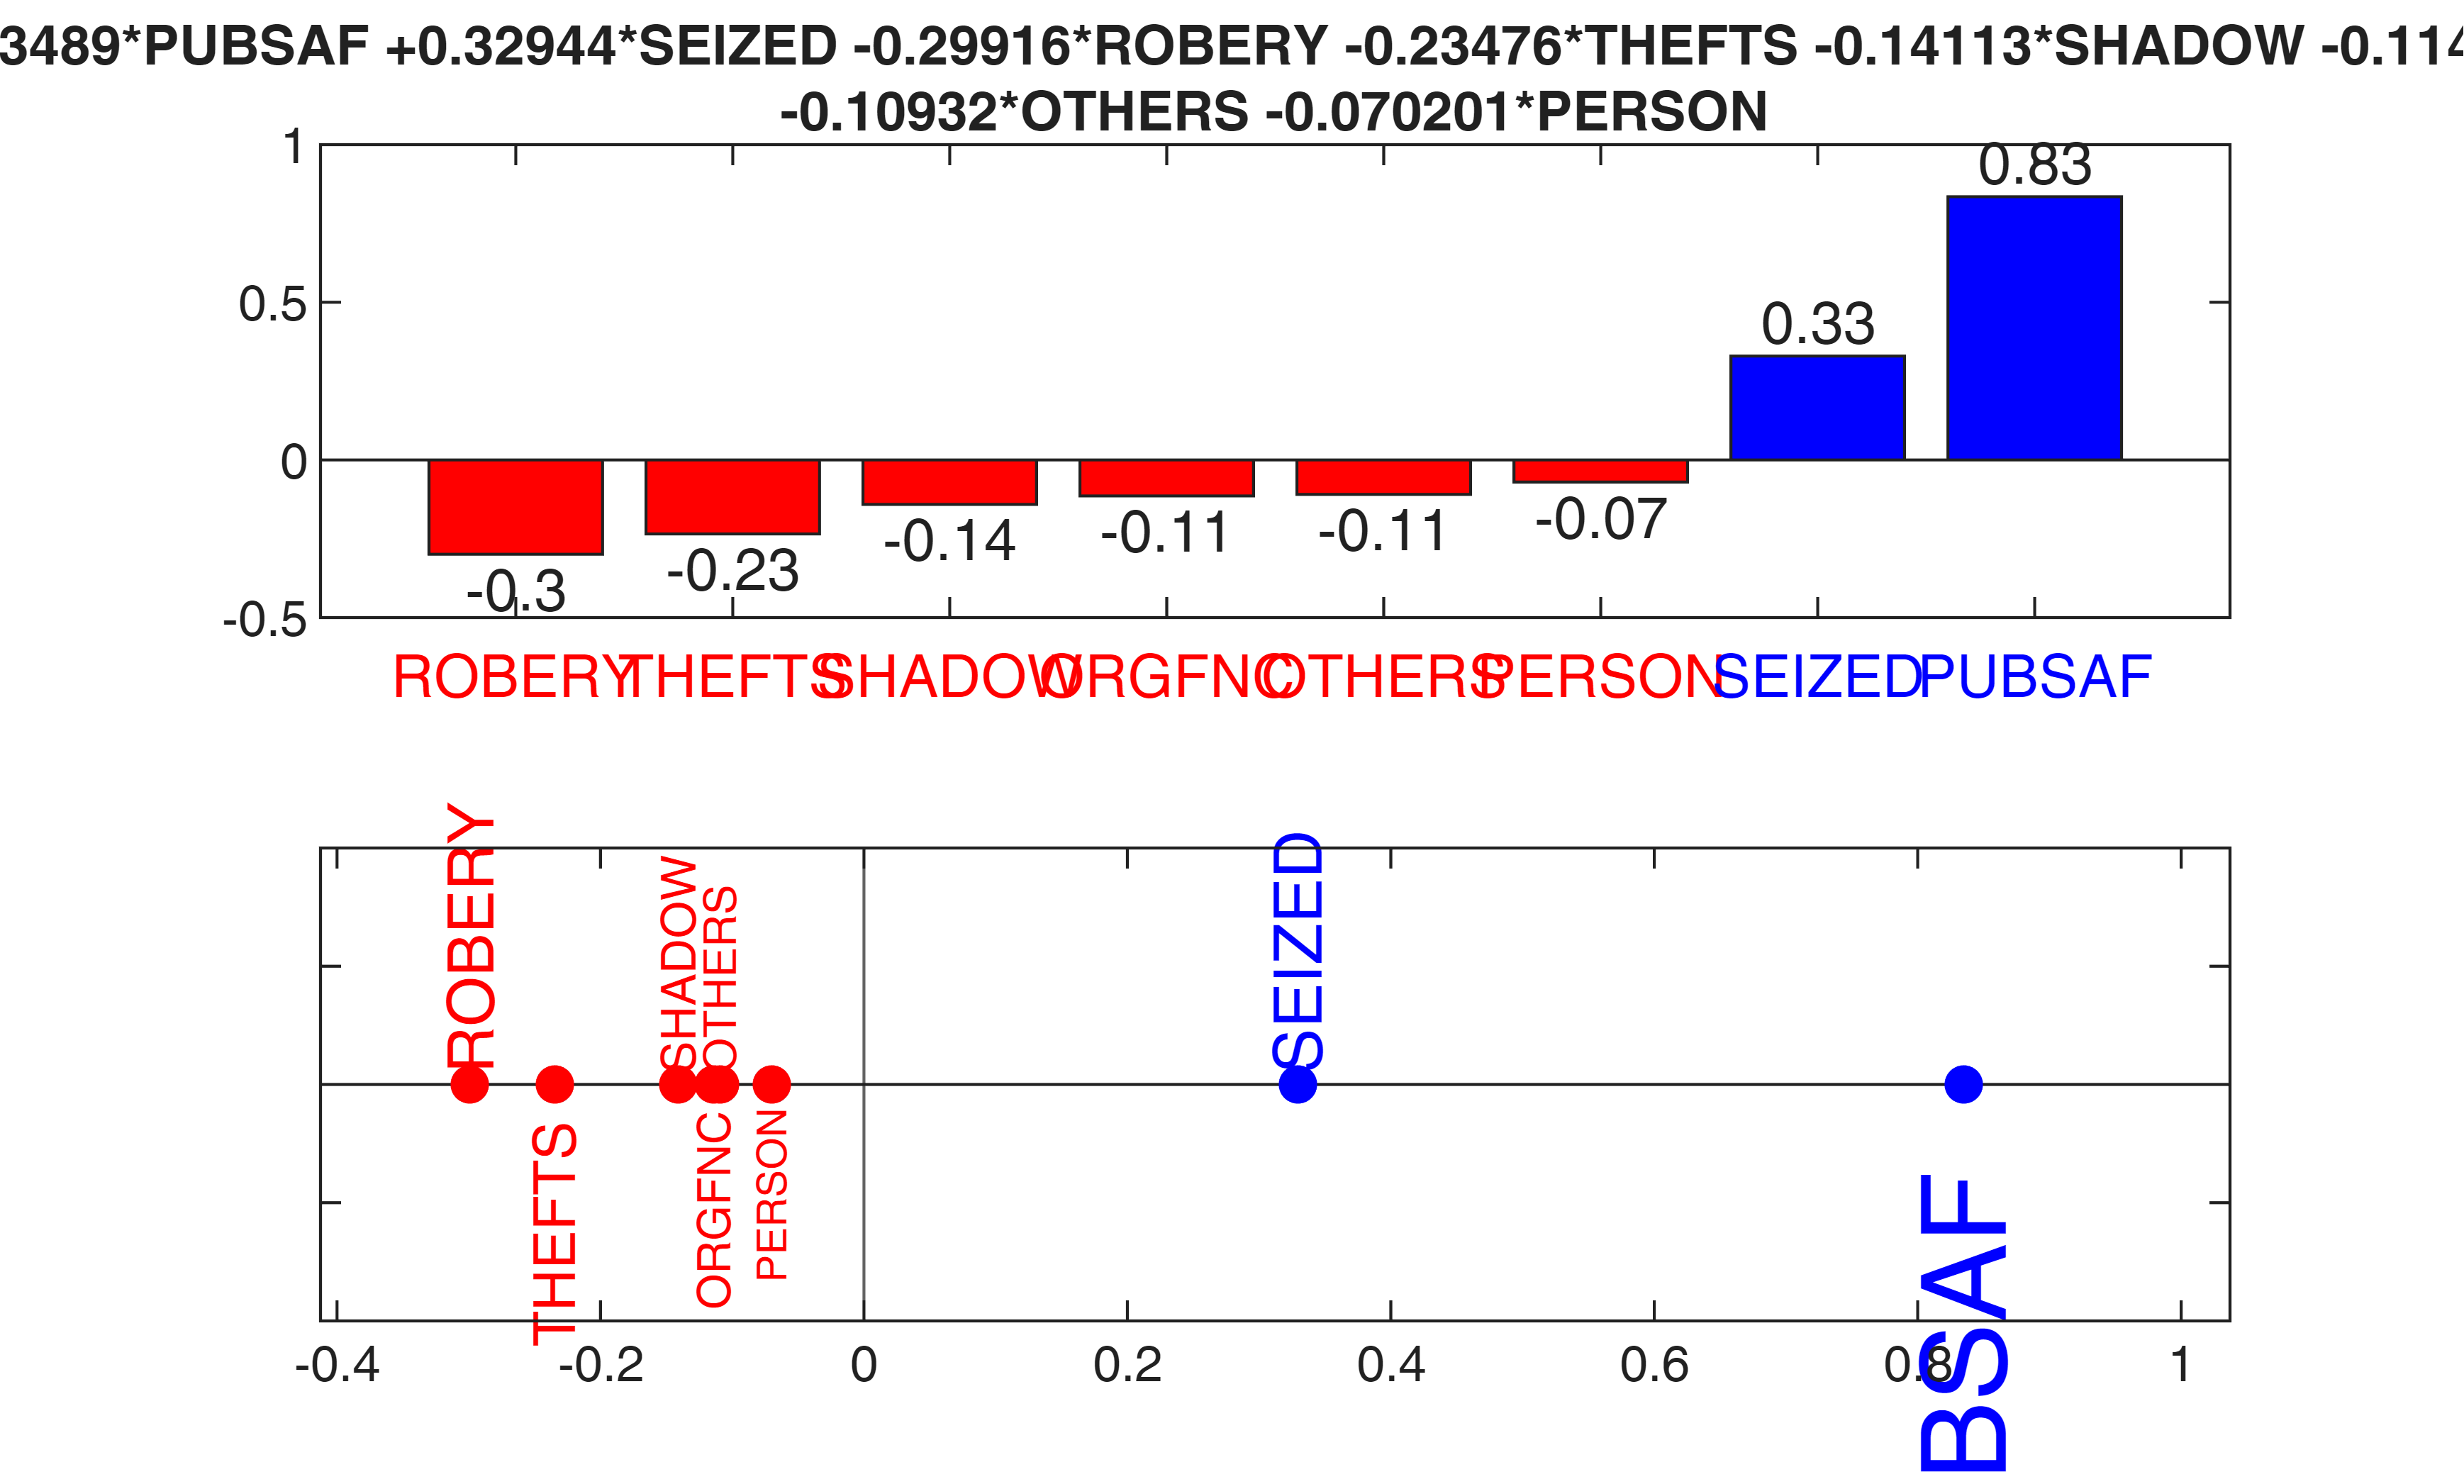</center>


<center>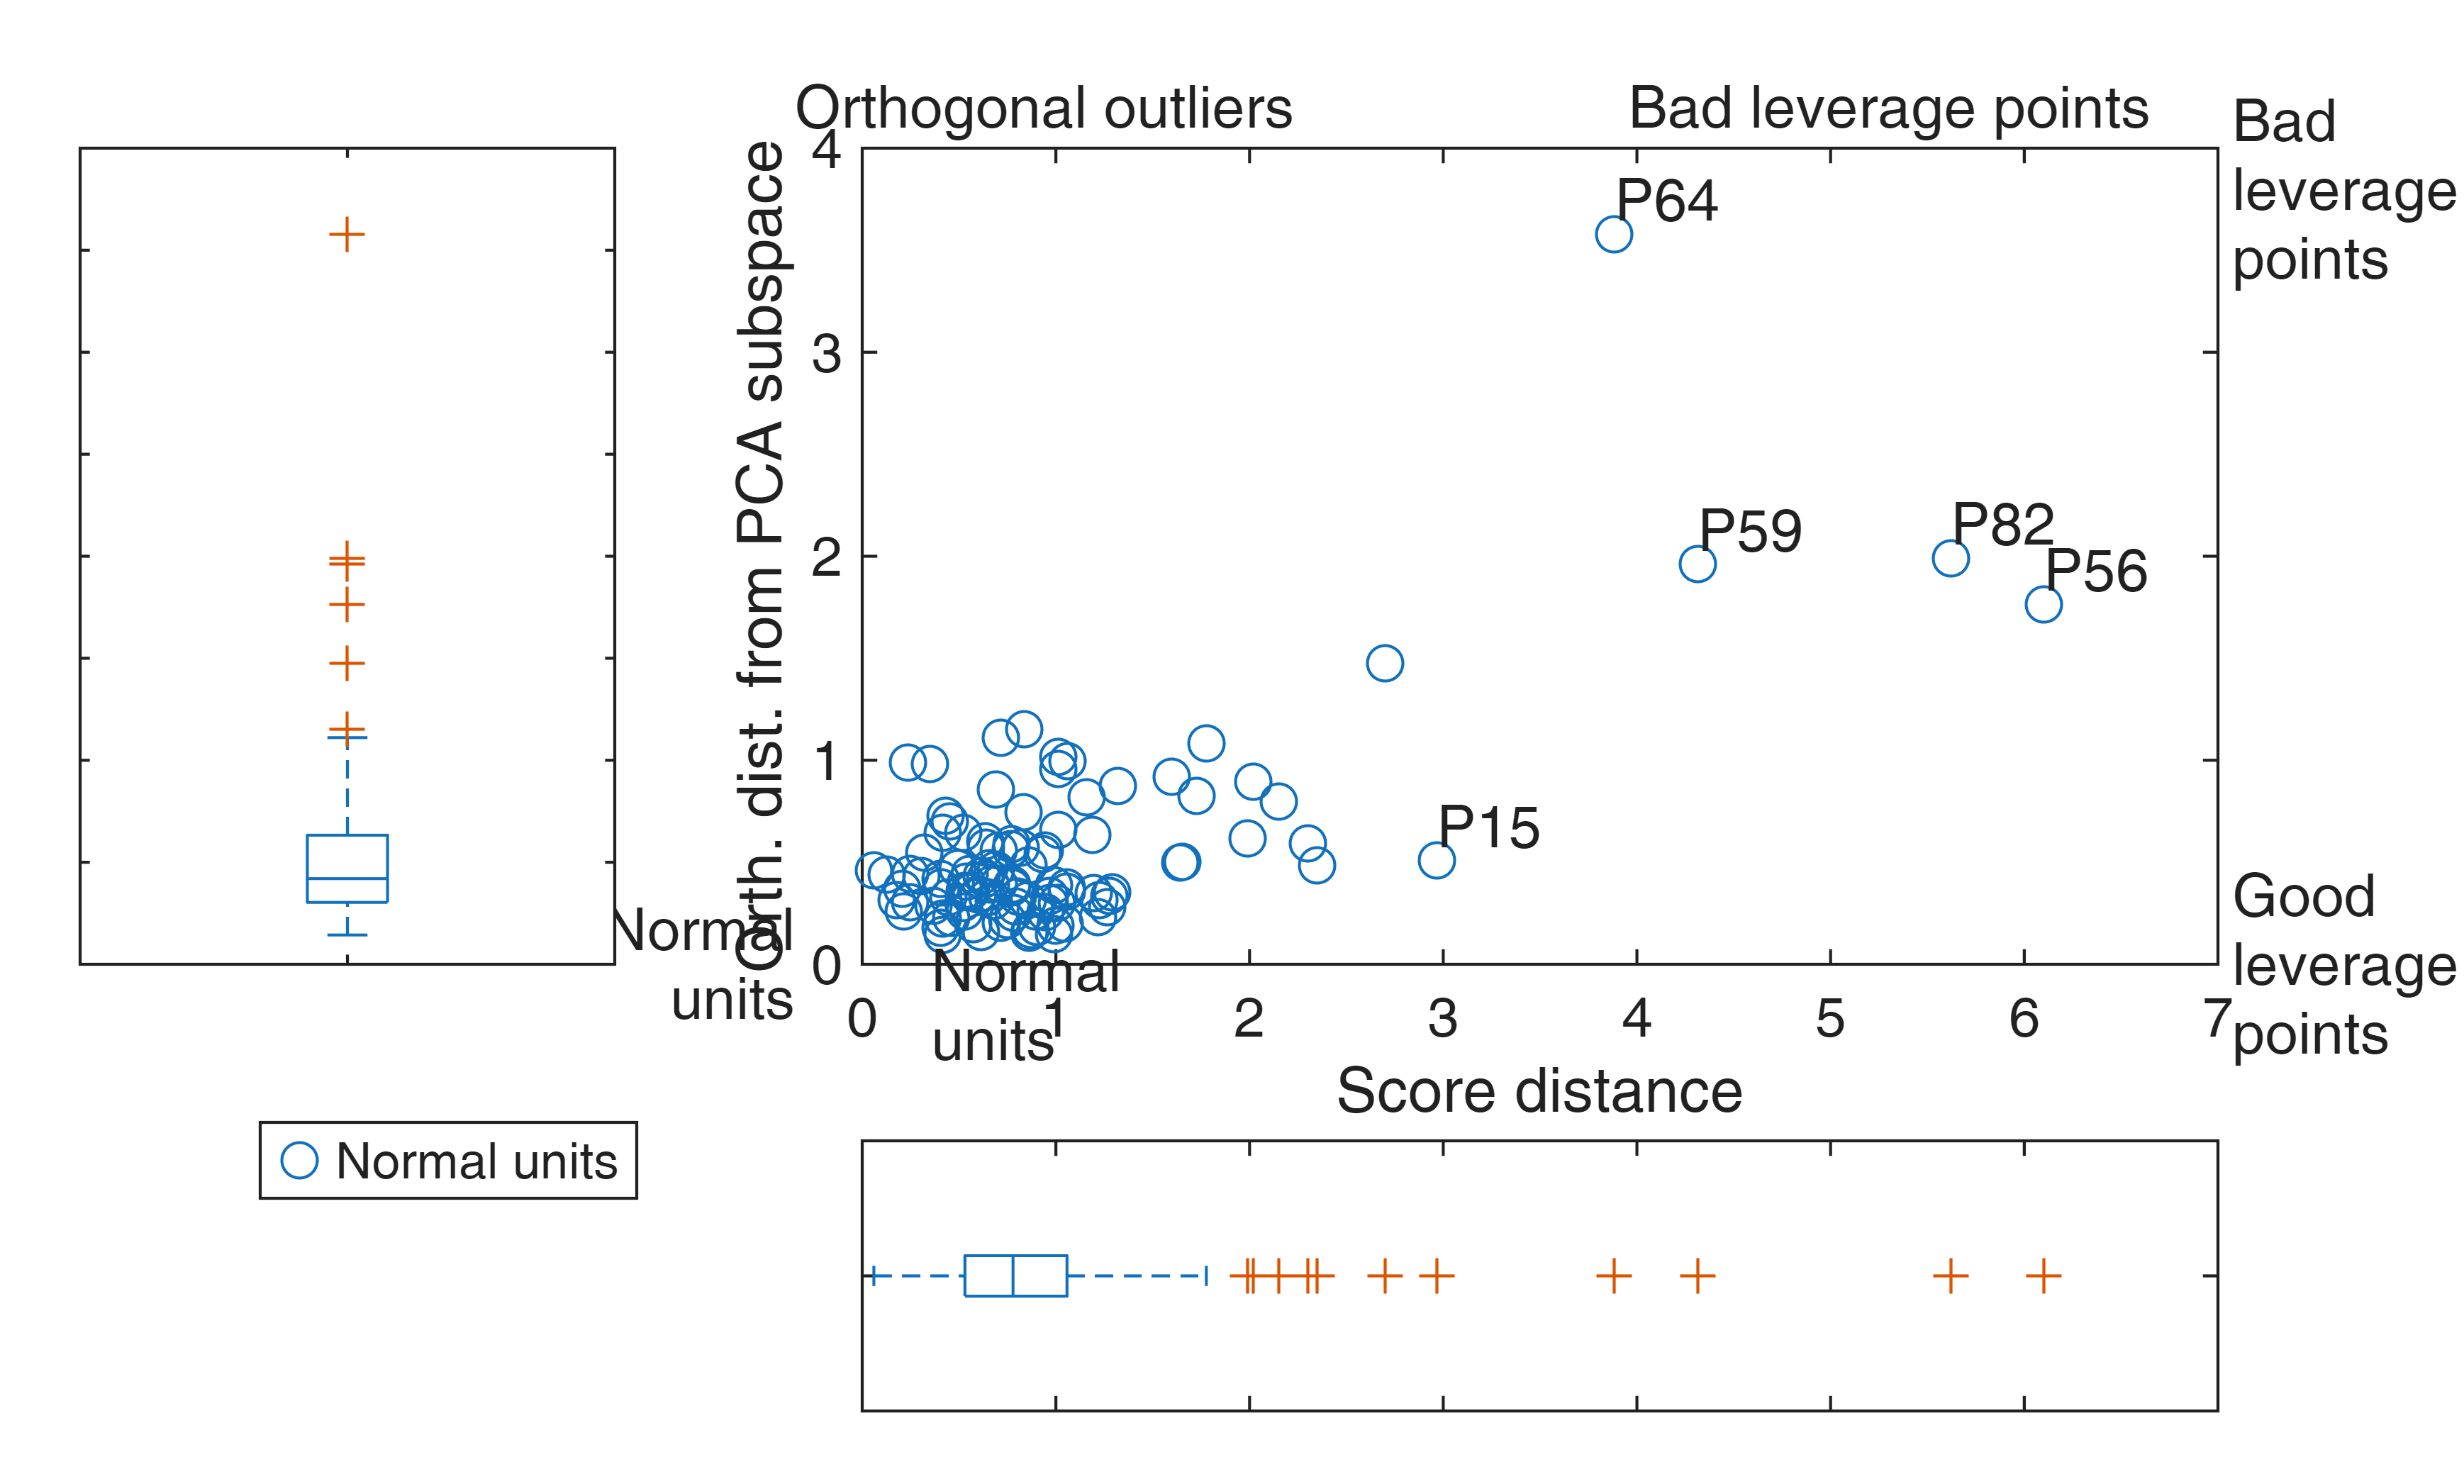</center>


<center>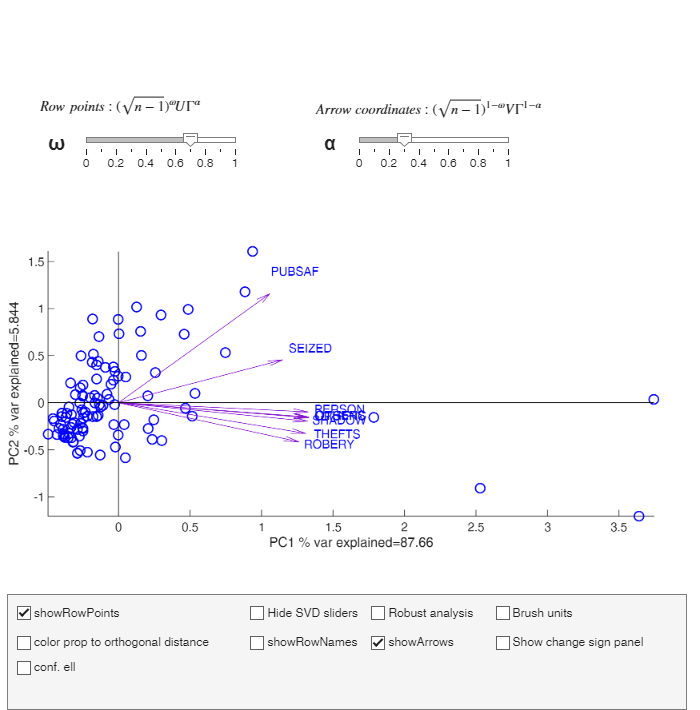</center>

## Outlier detection

In [3]:
close all
outFSM=FSM(Y{:,:},'bonflev',0.9999,'plots',0);

-------------------------
Signal detection loop
$d_min$(101,106)>99% Bonferroni level
----------------------------
Final output
Number of units declared as outliers=5


## Figure 3 right panel: Robust PCA analysis

The first PC already explains more than 0.95^v variability
In what follows we still extract the first 2 PCs
Initial correlation matrix
              PERSON    THEFTS    ROBERY    ORGFNC    PUBSAF    OTHERS    SEIZED    SHADOW
              ______    ______    ______    ______    ______    ______    ______    ______
    PERSON     1.00      0.81      0.75      0.92      0.54      0.91      0.81      0.88 
    THEFTS     0.81      1.00      0.83      0.85      0.41      0.84      0.70      0.84 
    ROBERY     0.75      0.83      1.00      0.77      0.46      0.81      0.66      0.76 
    ORGFNC     0.92      0.85      0.77      1.00      0.50      0.88      0.80      0.89 
    PUBSAF     0.54      0.41      0.46      0.50      1.00      0.56      0.46      0.47 
    OTHERS     0.91      0.84      0.81      0.88      0.56      1.00      0.80      0.84 
    SEIZED     0.81      0.70      0.66      0.80      0.46      0.80      1.00      0.76 
    SHADOW     0.88      0.84      0.76      0


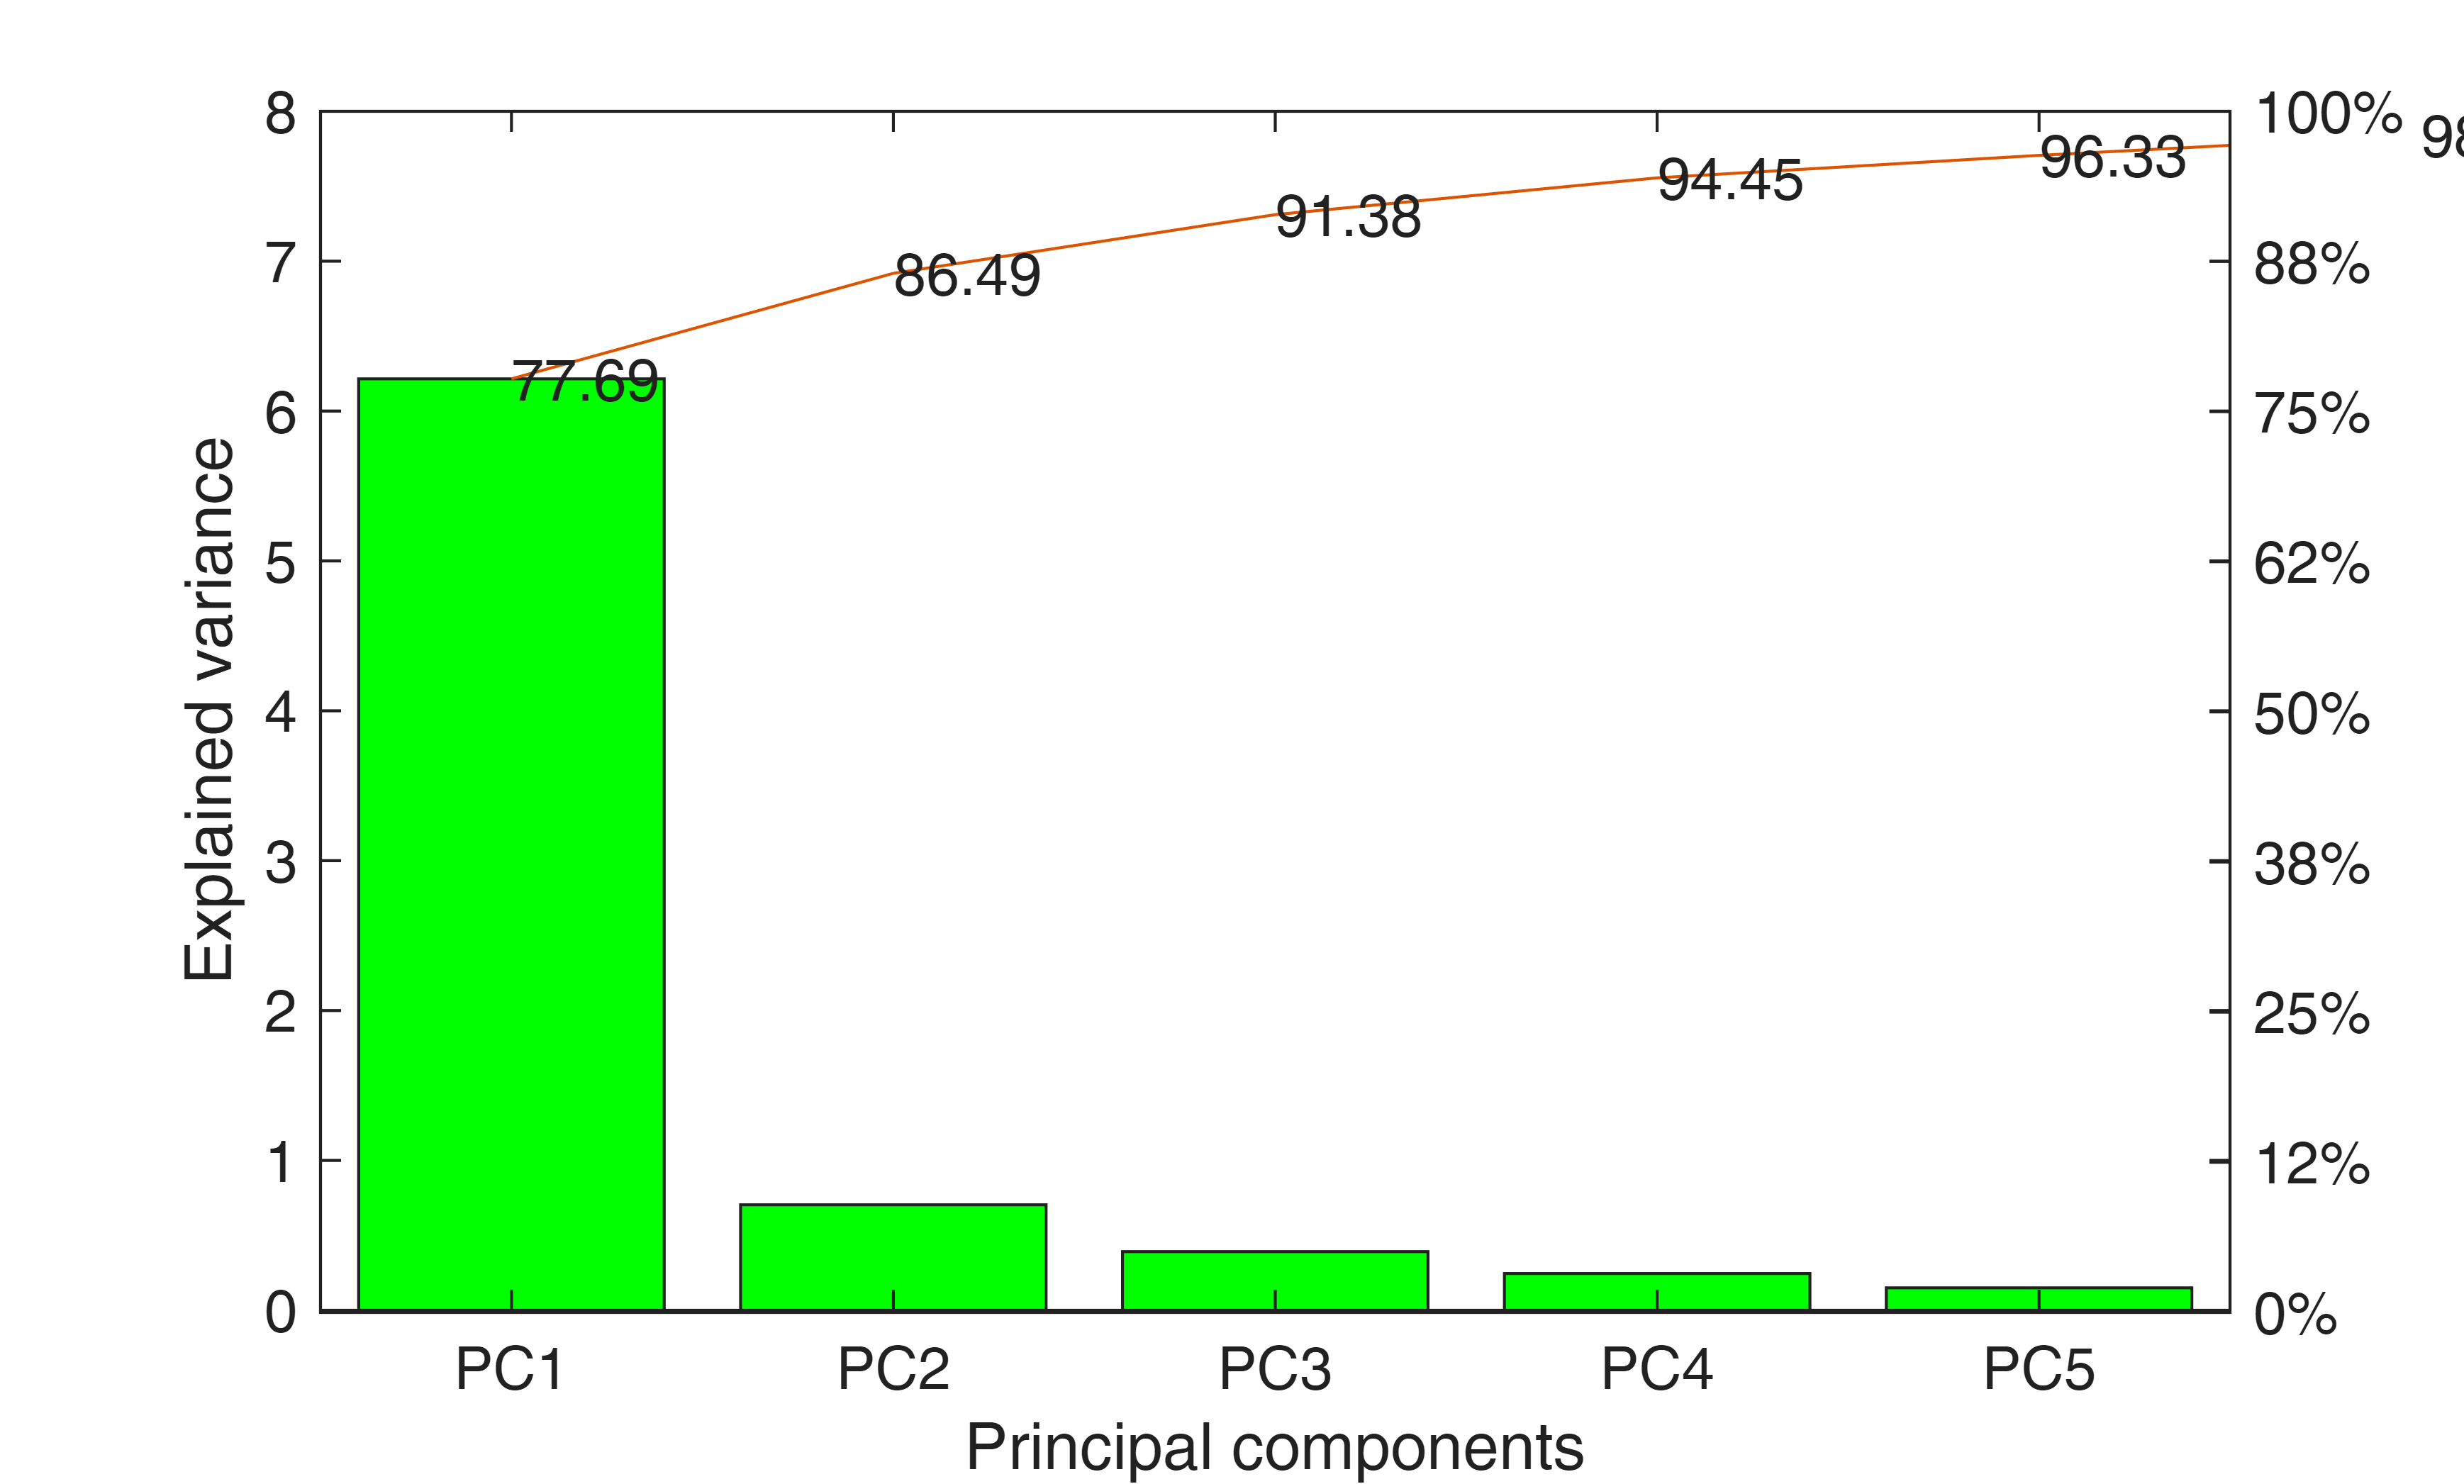


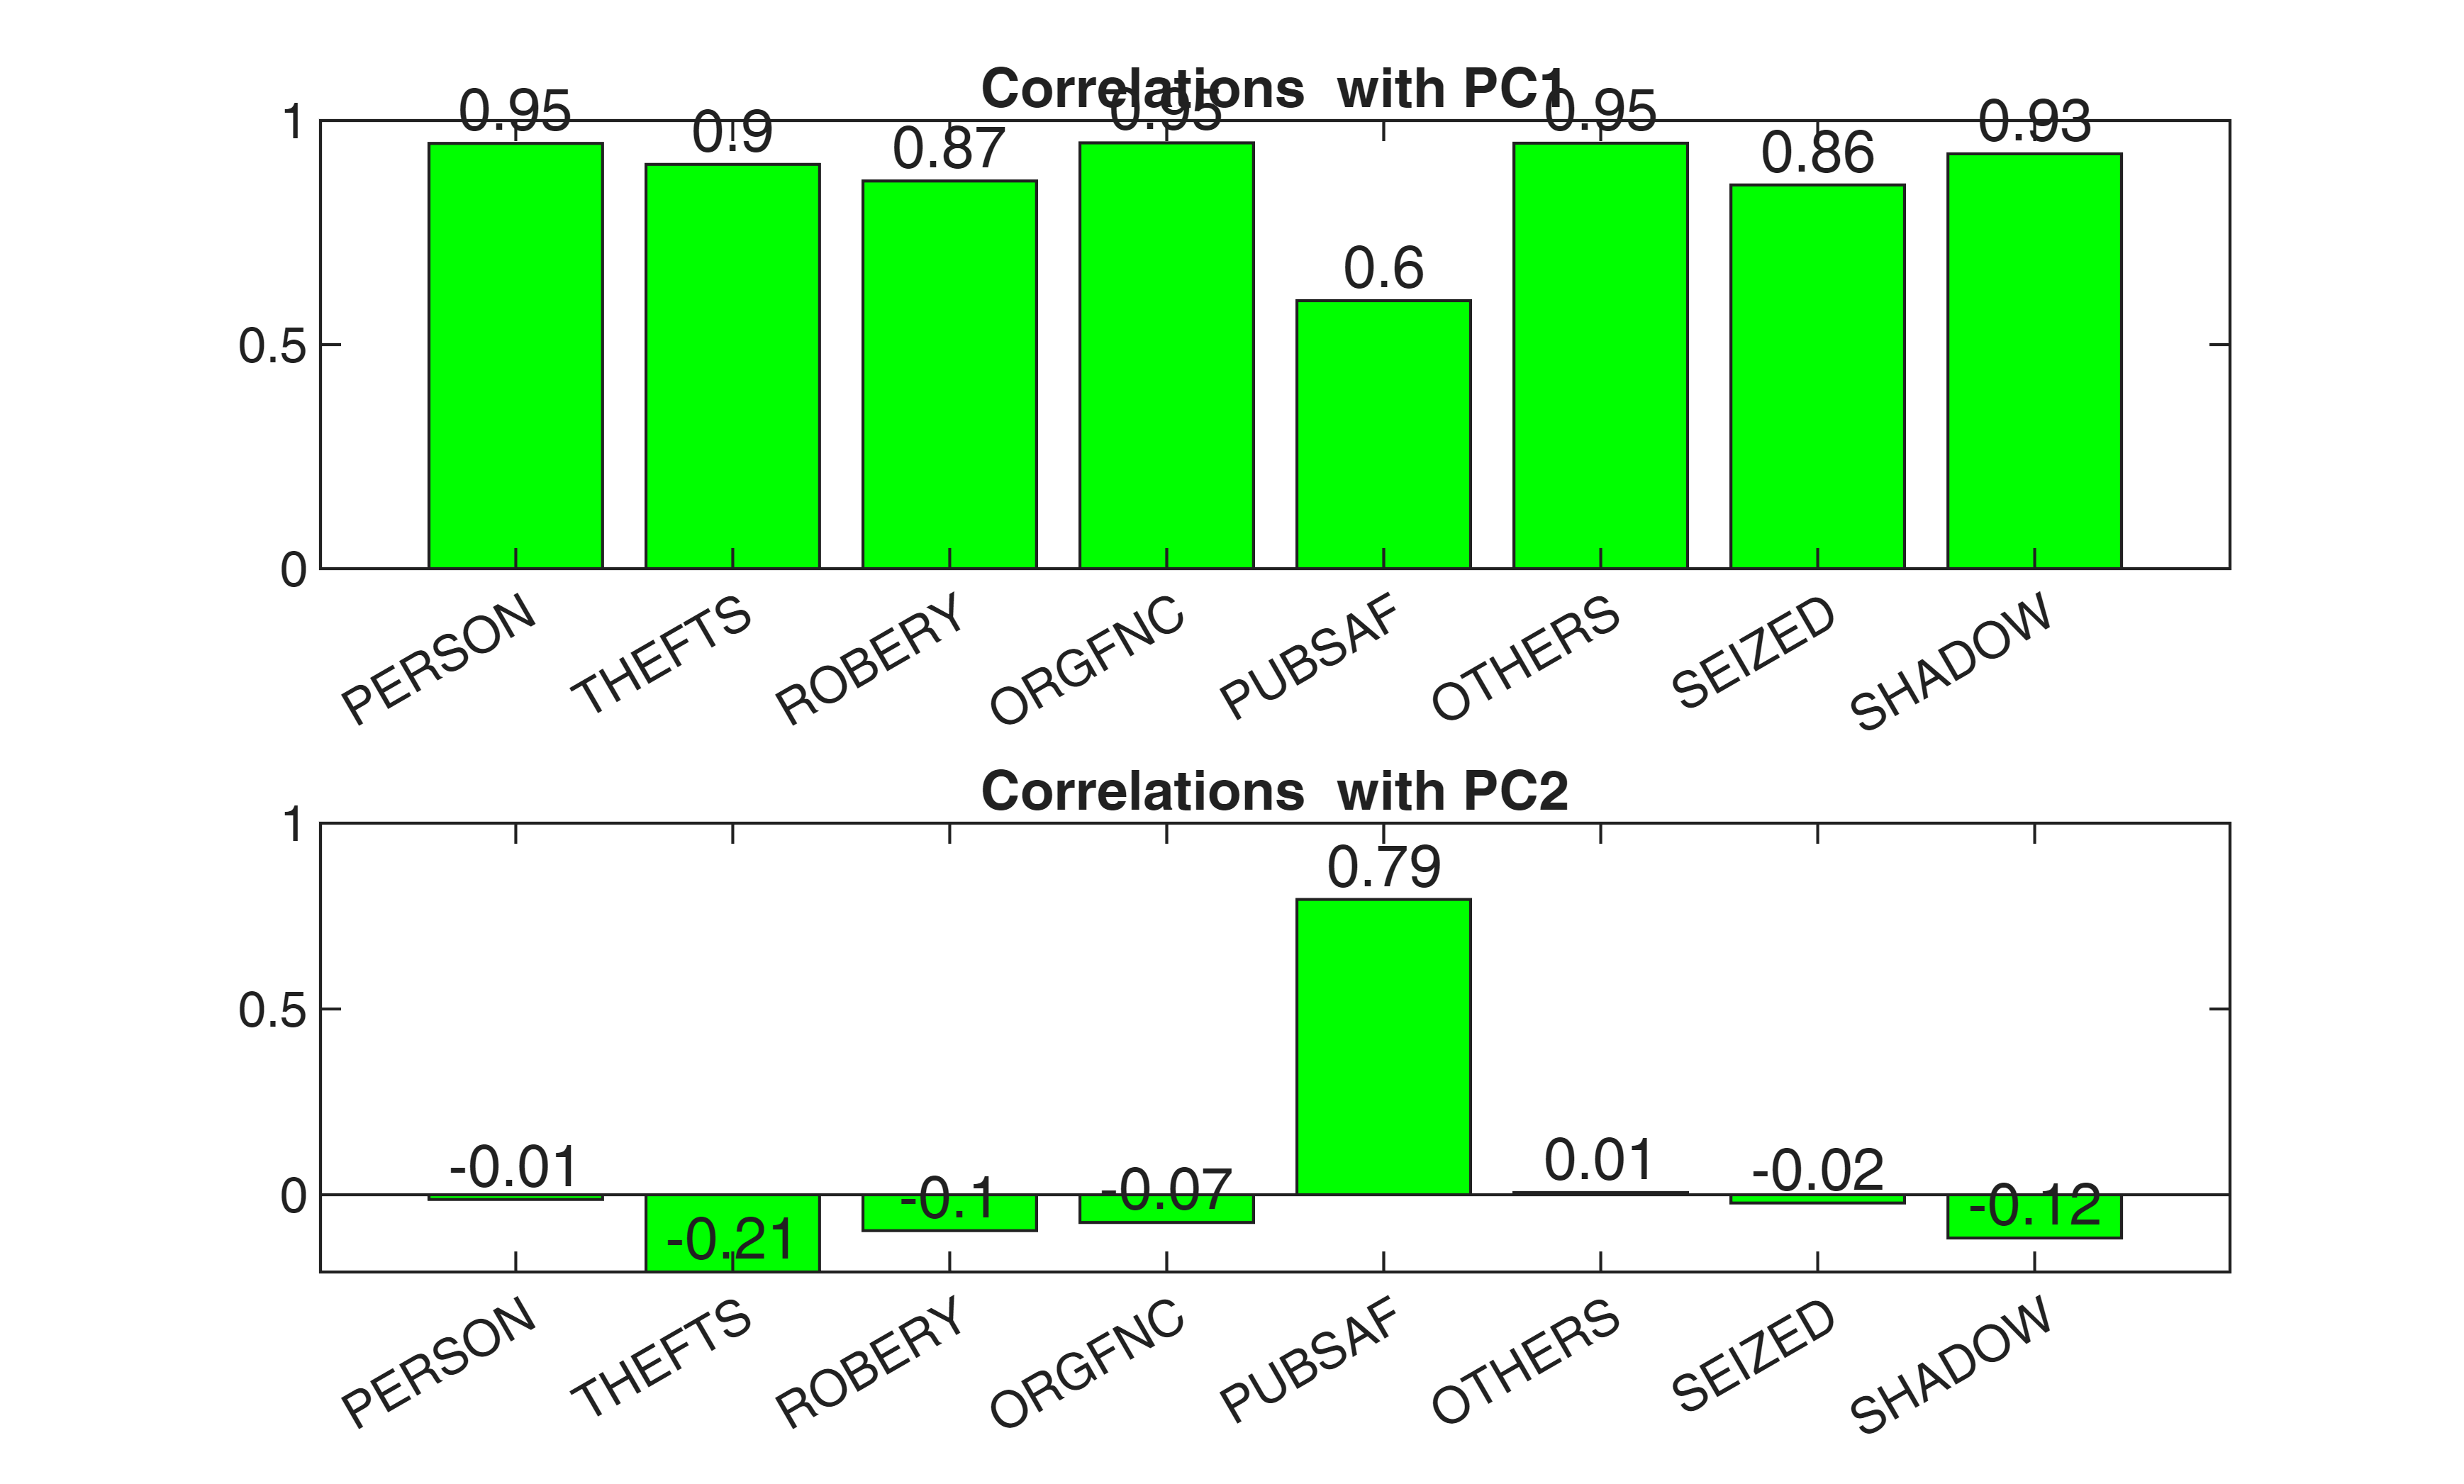

In [4]:
robust=struct;
n=height(Y);
seq=1:n;
robust.bsb=setdiff(seq,outFSM.outliers);
outFS=pcaFS(Y,"robust",robust,"smartEVchart",true);

<center>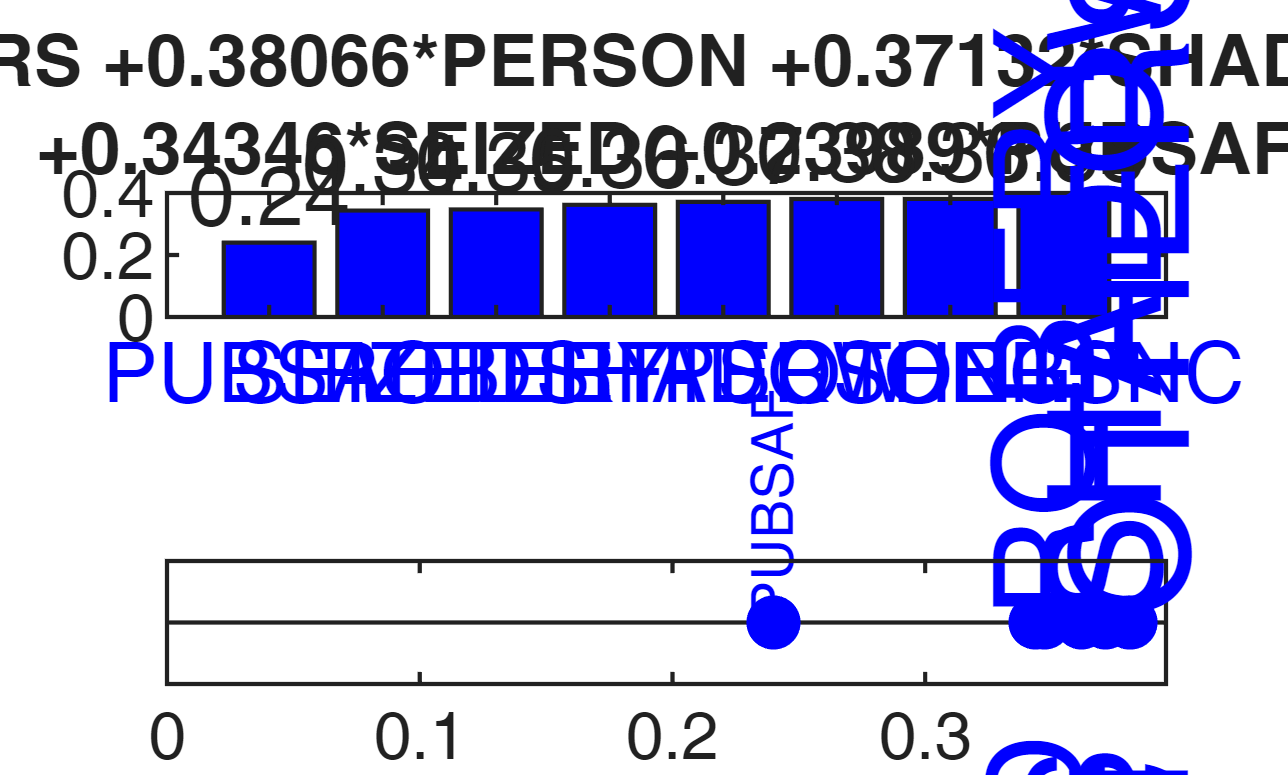</center>


<center>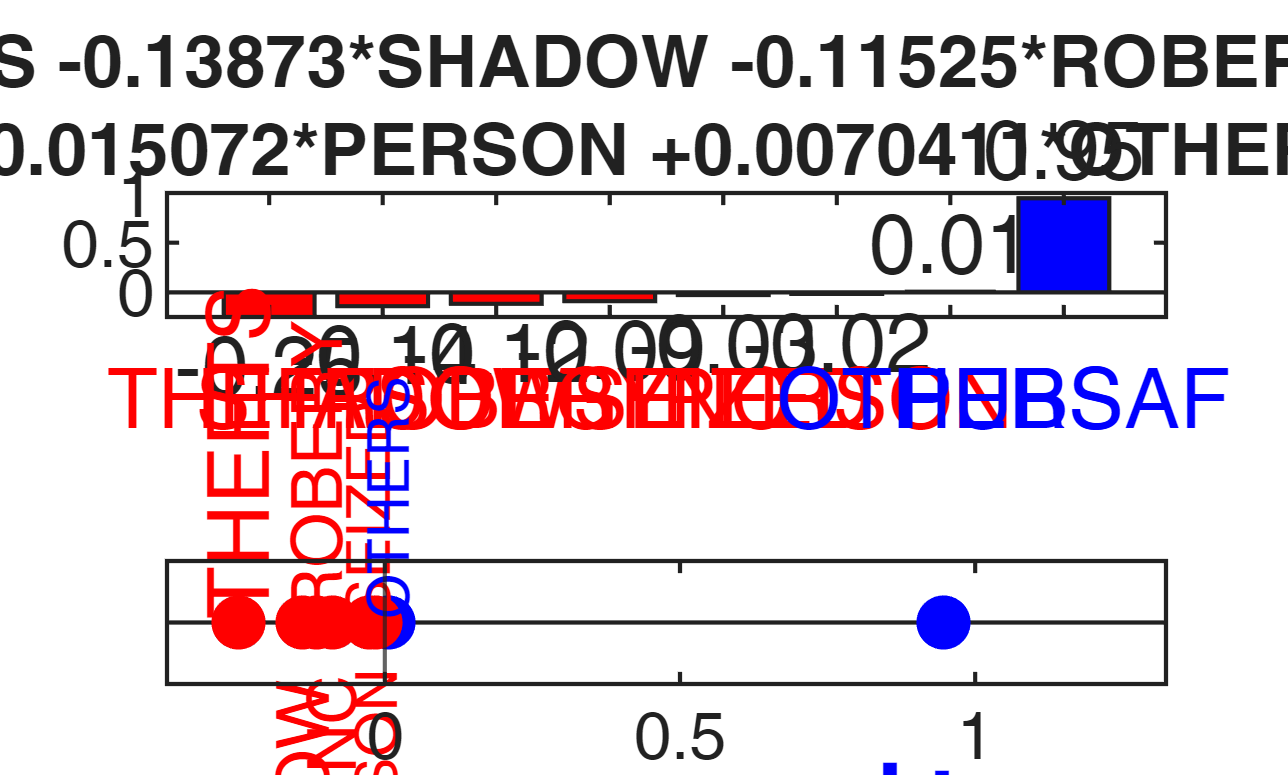</center>


<center>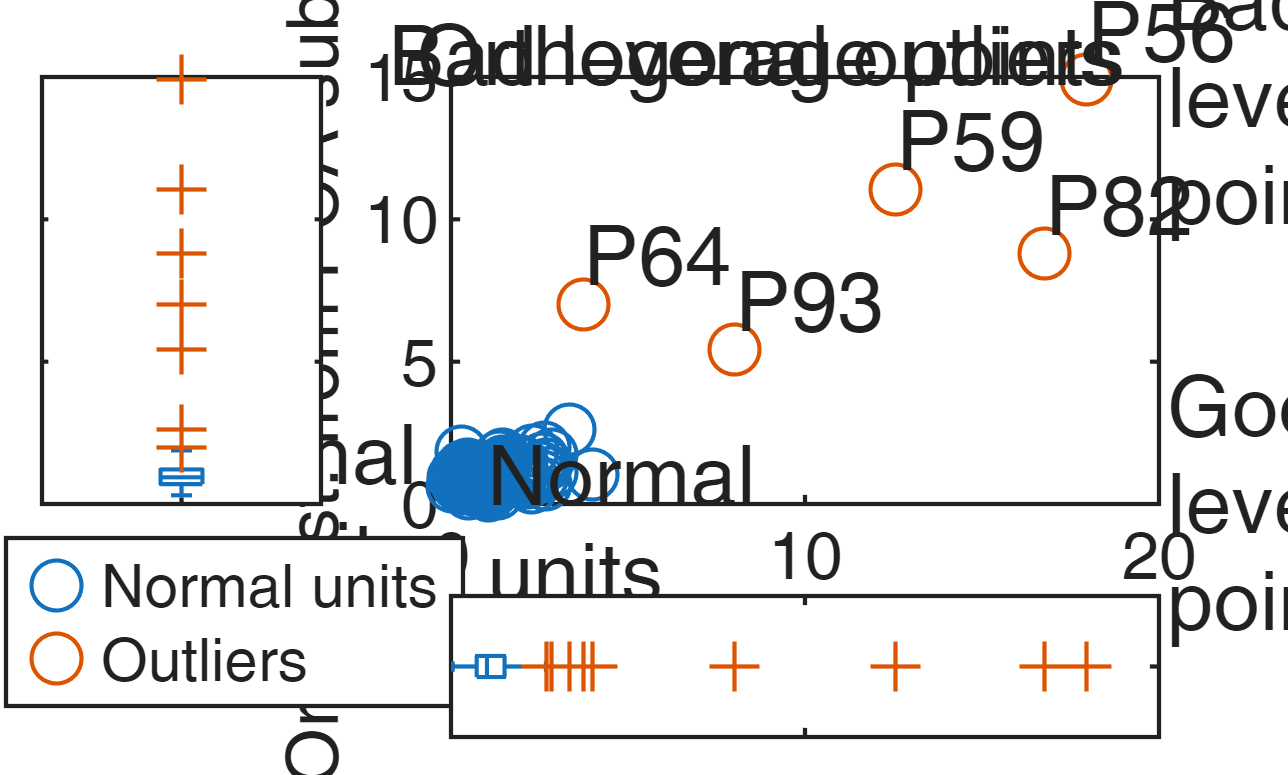</center>


<center>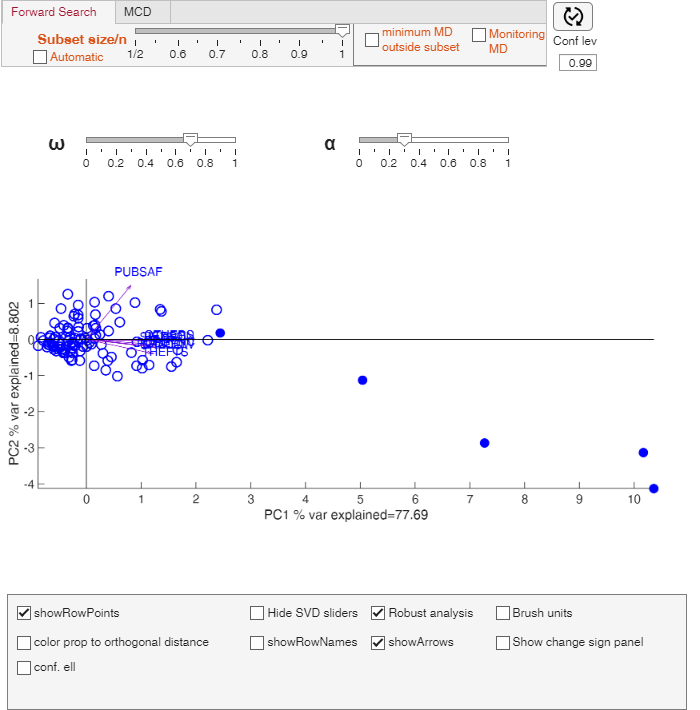</center>



In [5]:
% In the biplot APP to reproduce exactly the right panel of Figure 3
% 1) select the chechbox conf.ell.
% 2) select omega=0.3 in the top slider bar

## Figure 2: personalized scatter plot matrix with the 2 groups


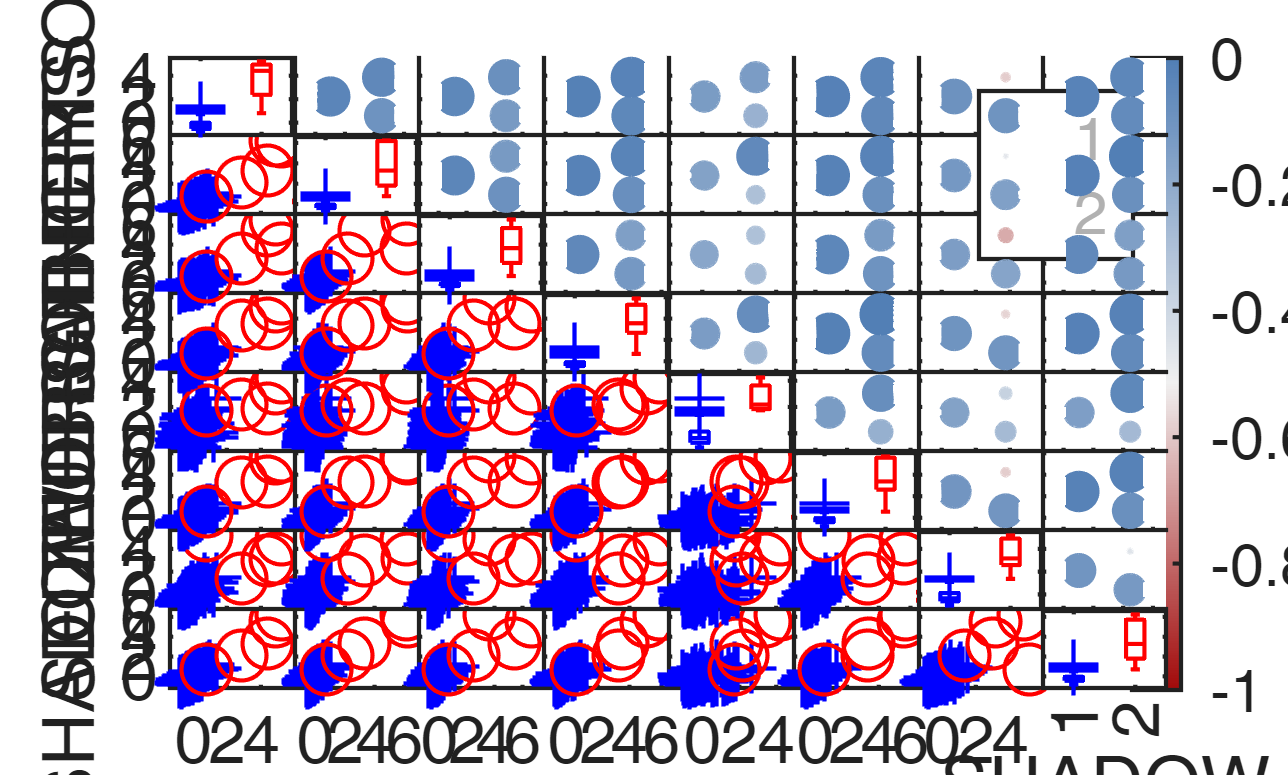

In [6]:
close all
group=ones(n,1);
group(outFSM.outliers)=2;
typespm=struct;
typespm.upper='circle';
spmplot(Y,'group',group,'dispopt','box','typespm',typespm);